SDF3 min: -0.9412864133027501
SDF3 max: 2.4641016151377544
UDF3 min: 0.0018690261467484426
UDF3 max: 2.4641016151377544


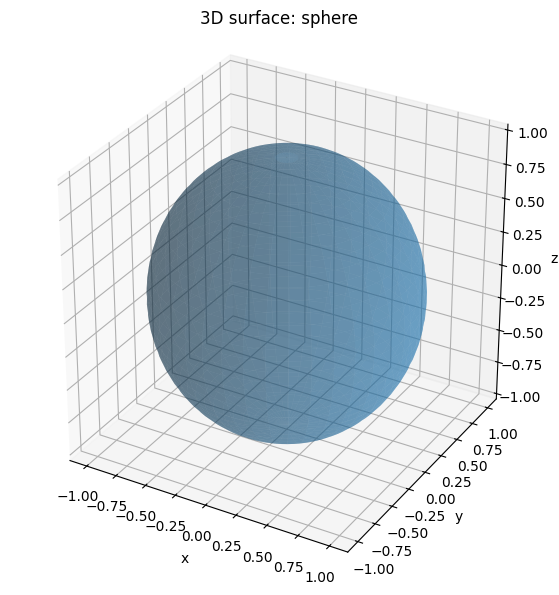

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# In 3D, the analogous surface is a sphere
# S = { p in R³ : ||p|| = R }
# p = (x, y, z)
# The distance from p to the origin is:||p|| = sqrt(x² + y² + z²)
# Therefore, the SDF of a sphere is: SDF(p) = ||p|| - R
# And the UDF is: UDF(p) = | ||p|| - R |
# The zero level set UDF(p) = 0 is the sphere surface.


N3D = 60

x3 = np.linspace(-2.0, 2.0, N3D)
y3 = np.linspace(-2.0, 2.0, N3D)
z3 = np.linspace(-2.0, 2.0, N3D)

X3, Y3, Z3 = np.meshgrid(x3, y3, z3, indexing="ij")
P3 = np.stack([X3, Y3, Z3], axis=-1)

R = 1.0

def sdf_sphere(X, Y, Z, R):
    return np.sqrt(X**2 + Y**2 + Z**2) - R


def udf_sphere(X, Y, Z, R):
    return np.abs(sdf_sphere(X, Y, Z, R))


SDF3 = sdf_sphere(X3, Y3, Z3, R)
UDF3 = udf_sphere(X3, Y3, Z3, R)

print("SDF3 min:", SDF3.min())
print("SDF3 max:", SDF3.max())
print("UDF3 min:", UDF3.min())
print("UDF3 max:", UDF3.max())


# We parametrize the sphere using two angles:
#  theta: angle around the z-axis
#  phi  : angle from top to bottom
#  x = R sin(phi) cos(theta)
#  y = R sin(phi) sin(theta)
#  z = R cos(phi)

theta = np.linspace(0, 2 * np.pi, 80)
phi = np.linspace(0, np.pi, 40)
Theta, Phi = np.meshgrid(theta, phi)

surface_x3 = R * np.sin(Phi) * np.cos(Theta)
surface_y3 = R * np.sin(Phi) * np.sin(Theta)
surface_z3 = R * np.cos(Phi)


fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    surface_x3,
    surface_y3,
    surface_z3,
    alpha=0.4,
    linewidth=0
)

ax.set_title("3D surface: sphere")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_box_aspect([1, 1, 1])

plt.show()

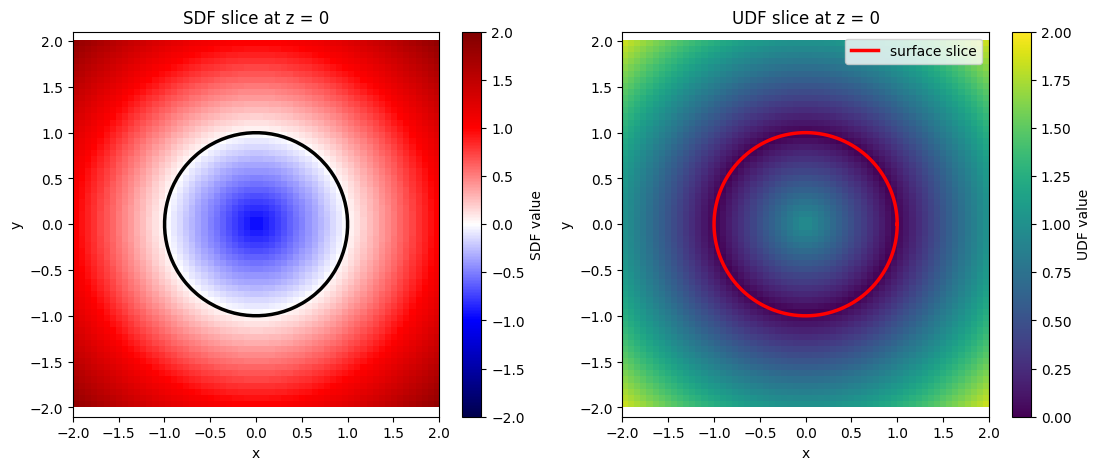

In [4]:

z0_index = np.argmin(np.abs(z3 - 0.0))

UDF_slice_z0 = UDF3[:, :, z0_index]
SDF_slice_z0 = SDF3[:, :, z0_index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(
    SDF_slice_z0.T,
    extent=[x3.min(), x3.max(), y3.min(), y3.max()],
    origin="lower",
    cmap="seismic",
    vmin=-2,
    vmax=2
)

axes[0].contour(
    x3,
    y3,
    SDF_slice_z0.T,
    levels=[0],
    colors="black",
    linewidths=2.5
)

axes[0].set_title("SDF slice at z = 0")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].axis("equal")
plt.colorbar(im0, ax=axes[0], label="SDF value")


im1 = axes[1].imshow(
    UDF_slice_z0.T,
    extent=[x3.min(), x3.max(), y3.min(), y3.max()],
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=2
)

# Instead of contouring UDF at level 0,
# we draw the analytical circle that appears in the slice z = 0.
circle_theta = np.linspace(0, 2 * np.pi, 400)
circle_x = R * np.cos(circle_theta)
circle_y = R * np.sin(circle_theta)

axes[1].plot(
    circle_x,
    circle_y,
    color="red",
    linewidth=2.5,
    label="surface slice"
)

axes[1].set_title("UDF slice at z = 0")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].axis("equal")
axes[1].legend()
plt.colorbar(im1, ax=axes[1], label="UDF value")

plt.show()